## MTF — From Optics to Measurement

Every optical system (a satellite sensor, a cinema camera, an MRI scanner, a smartphone lens...) introduces a blur. Not because of a defect, but because of physics.

Light diffracted by an aperture, pixels that integrate over a finite area, motion during exposure: all of these constributors smear the image of a point source into a spread function. The sharpness of the final image depends on how narrow that spread is. The **Modulation Transfer Function (MTF)** is the universal metric that quantifies this. It tells you, for each spatial frequency, how much contrast is preserved between the object and its image.

An MTF of 1.0 at a given frequency means perfect contrast.
An MTF of 0.0 means that frequency is completely lost.

---

**This notebook covers:**

0. What does MTF look like visually
1. MTF as the optical signature of an imaging system
2. Slanted edge method: measuring MTF from an image
3. Numerical sensitivities: truncation, windowing, FFT size, noise

---

**Warning:**
- All derivations in this notebook assume a **linear shift-invariant system (LSI)**.
In practice, real imaging systems are only approximately shift-invariant: the PSF may vary across the field of view due to optical aberrations or detector effects. As a result, the MTF estimated from a slanted edge should be interpreted as a **local measurement** of image quality.
- In this notebook, Gaussian PSFs are used for clarity and analytical simplicity. However, real diffraction-limited optical systems are better described by an Airy pattern (Bessel J1), leading to non-monotonic MTFs with oscillations and a sharp cutoff frequency. The Gaussian model should therefore be seen as an approximation of the system blur, not a physically exact representation.

---

*Toolbox functions imported from `fonctions/QI.py`.
Full source available as part of consulting engagements — floragabriagues.github.io*

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from fonctions.QI import compute_MTF_slanted_edge, fit_MTF_contributors

# ── Style ──────────────────────────────────────────────────────────────
DARK_BG  = "#0d1117"
PANEL_BG = "#0d1520"
GRID_COL = "#1e2d3d"
TEXT_COL = "#e6edf3"
MUTED    = "#8b949e"
TURQUOISE = "#53fef0"
ORANGE   = "#f78166"
LIGHT_GREEN = "#80e76bca"
DARK_GREEN = "#0c8526"
YELLOW   = "#e3b341"
PURPLE   = "#bc8cff"
BLUE     = "#2f3dd7ff"
RED      = "#b92289"
RED      = "#54b922"

plt.rcParams.update({
    "font.family":     "monospace",
    "text.color":      TEXT_COL,
    "axes.labelcolor": TEXT_COL,
    "xtick.color":     MUTED,
    "ytick.color":     MUTED,
})

def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.grid(True, color=GRID_COL, linewidth=0.5, linestyle=":", alpha=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

def watermark(fig):
    fig.text(0.99, 0.01, "EO_Toolbox", fontsize=7,
             color=MUTED, ha="right", va="bottom", alpha=0.5)

## 0. What does MTF look like visually ?

Before any equation, here is what MTF degradation looks like on a real signal.
The target below is a chirp, a sinusoid whose spatial frequency increases continuously from left to right.
An ideal system reproduces it exactly. A real system blurs it: contrast between black and white bars decreases as the bars get finer. Until they become indistinguishable. The MTF curve on the right is simply the plot of this contrast loss as a function of spatial frequency.

**Reading the MTF:**
- MTF = 1.0 → perfect contrast at this frequency
- MTF = 0.5 → contrast halved, bars are faint but visible
- MTF = 0.0 → frequency completely lost, bars invisible

The Nyquist frequency (0.5 cycles/px) is the highest frequency a sampled system can theoretically represent. Beyond it, aliasing occurs.

C:\Users\floga\AppData\Local\Temp\ipykernel_25704\1928968925.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


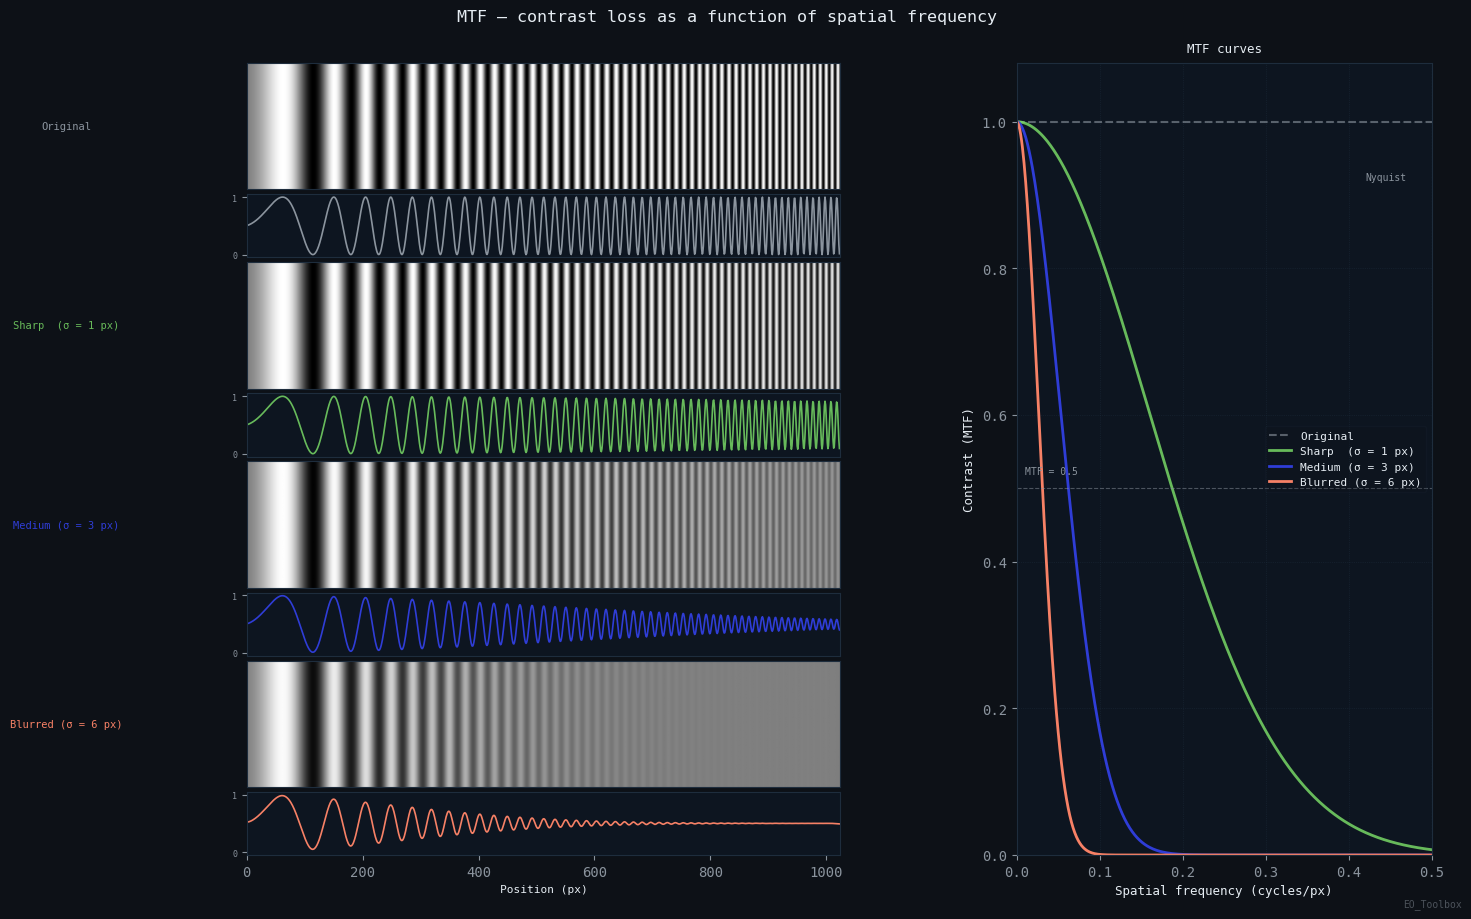

In [35]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

plt.close('all')

N        = 1024
x        = np.arange(N)
dx       = 1.0
n_rows   = 30

freq_inst = np.linspace(0.001, 0.1, N)
phase     = 2 * np.pi * np.cumsum(freq_inst)
target    = 0.5 * (1 + np.sin(phase))

sigmas_dict = {
    "Original":            (0.0,  MUTED),
    "Sharp  (σ = 1 px)":   (1.0,  LIGHT_GREEN),
    "Medium (σ = 3 px)":   (3.0,  BLUE),
    "Blurred (σ = 6 px)":  (6.0,  ORANGE),
}

targets = {}
for label, (sigma, color) in sigmas_dict.items():
    signal = gaussian_filter1d(target, sigma=sigma) if sigma > 0 else target.copy()
    targets[label] = (signal, color)

n_targets = len(targets)

fig = plt.figure(figsize=(15, 9), facecolor=DARK_BG)
fig.suptitle("MTF — contrast loss as a function of spatial frequency", fontsize=12, color=TEXT_COL, y=1.01)
gs = fig.add_gridspec(n_targets * 2, 2, width_ratios=[2, 1.4], height_ratios=[2, 1] * n_targets, hspace=0.05, wspace=0.35, left=0.18, right=0.97, top=0.95, bottom=0.07)
ax_mtf = fig.add_subplot(gs[:, 1])

for row, (label, (signal, color)) in enumerate(targets.items()):

    # ── image (barres) ──
    ax_img = fig.add_subplot(gs[row * 2, 0])
    ax_img.imshow(
        np.tile(signal, (n_rows, 1)),
        cmap="gray", aspect="auto",
        vmin=0, vmax=1,
        extent=[0, N, 0, 1]
    )
    ax_img.set_yticks([])
    ax_img.set_xticks([])
    ax_img.set_ylabel(label, fontsize=7.5, color=color, rotation=0, labelpad=130, va="center")
    for spine in ax_img.spines.values():
        spine.set_edgecolor(GRID_COL)
    ax_img.set_facecolor(DARK_BG)

    # ── profil ──
    ax_prof = fig.add_subplot(gs[row * 2 + 1, 0])
    ax_prof.plot(x, signal, color=color, lw=1.2)
    ax_prof.set_xlim(0, N)
    ax_prof.set_ylim(-0.05, 1.05)
    ax_prof.set_yticks([0, 1])
    ax_prof.tick_params(axis='y', labelsize=6, colors=MUTED)
    ax_prof.set_facecolor(PANEL_BG)
    for spine in ax_prof.spines.values():
        spine.set_edgecolor(GRID_COL)
    if row < n_targets - 1:
        ax_prof.set_xticks([])
    else:
        ax_prof.set_xlabel("Position (px)", fontsize=8)

# ── MTF curves ──
freq_ana = np.linspace(0, 0.5, 500)

for label, (sigma, color) in sigmas_dict.items():
    if sigma == 0:
        ax_mtf.plot(freq_ana, np.ones_like(freq_ana), color=color, lw=1.5, linestyle="--", label=label, alpha=0.6)
    else:
        MTF_ana = np.exp(-2 * (np.pi * sigma * freq_ana) ** 2)
        ax_mtf.plot(freq_ana, MTF_ana, color=color, lw=2, label=label)

ax_mtf.axhline(0.5, color=MUTED, lw=0.8, linestyle="--", alpha=0.5)
ax_mtf.text(0.01, 0.52, "MTF = 0.5", fontsize=7, color=MUTED)
ax_mtf.axvline(0.5, color=MUTED, lw=0.8, linestyle=":", alpha=0.4)
ax_mtf.text(0.47, 0.92, "Nyquist", fontsize=7, color=MUTED, ha="right")

ax_mtf.set_xlim(0, 0.5)
ax_mtf.set_ylim(0, 1.08)
ax_mtf.set_xlabel("Spatial frequency (cycles/px)", fontsize=9)
ax_mtf.set_ylabel("Contrast (MTF)", fontsize=9)
ax_mtf.set_title("MTF curves", fontsize=9, color=TEXT_COL, pad=8)
ax_mtf.legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

style_ax(ax_mtf)
watermark(fig)
plt.tight_layout()
plt.show()

## 1. MTF as the optical signature of a system
### From object to image
Any linear shift-invariant optical system can be fully characterized by its **Point Spread Function (PSF)**: the image of an ideal point source.
The image formation process is a convolution:

    image(x) = object(x) ★ PSF(x)

In the frequency domain, convolution becomes multiplication:
    Image(f) = Object(f) × OTF(f)
where **OTF** is the Optical Transfer Function: the Fourier transform of the PSF.

The **MTF** is its modulus:

    MTF(f) = |OTF(f)|

### What MTF tells you

MTF(f) = 1 → contrast fully preserved at frequency f  
MTF(f) = 0 → contrast null at this frequency but if the MTF rises again beyond this zero, the frequency is transmitted with inverted contrast (phase reversal)

The MTF is always ≥ 0 as it is a modulus. The underlying OTF can change sign after its first zero, producing a local rise in the MTF with a phase reversal of π — fine structures then appear with inverted contrast. This occurs in defocused or strongly aberrated systems.

The MTF is always 1 at f=0 (uniform field) and reaches 0 at the **cutoff frequency**, beyond which the system cannot resolve any detail. 
Between these two points, the shape depends on the system: a well-corrected optic produces a smooth monotonic decrease, while defocus, aberrations, or digital sharpening can introduce oscillations or local rises.

### MTF is a product of contributors

In a real imaging system, several physical effects blur the image independently.
Because each is a convolution, their MTFs multiply:

    MTF_total(f) = MTF_optics(f) × MTF_detector(f) × MTF_motion(f) × ...

This is the key equation for image quality budgeting.

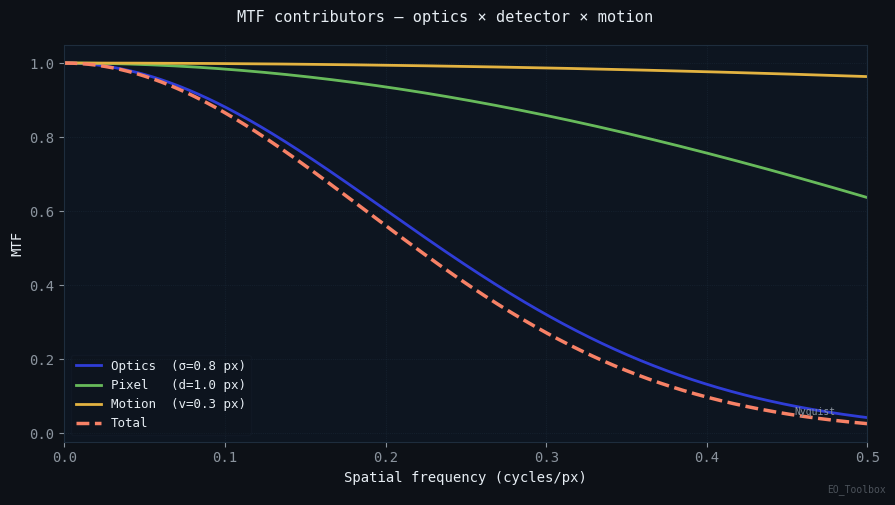

In [36]:
plt.close('all')

freq = np.linspace(0, 0.5, 500)

# individual contributors analytical approximations
sigma_optics = 0.8   # px — optical blur (diffraction + aberrations) simplified model
d_pixel      = 1.0   # px — pixel integration width
v_smear      = 0.3   # px — motion smear

MTF_optics   = np.exp(-2 * (np.pi * sigma_optics * freq) ** 2)
MTF_pixel    = np.abs(np.sinc(freq * d_pixel))
MTF_motion   = np.abs(np.sinc(freq * v_smear))
MTF_total    = MTF_optics * MTF_pixel * MTF_motion

fig, ax = plt.subplots(figsize=(9, 5), facecolor=DARK_BG)
style_ax(ax)
fig.suptitle("MTF contributors — optics × detector × motion", fontsize=11, color=TEXT_COL)

ax.plot(freq, MTF_optics, color=BLUE,   lw=2,   label=f"Optics  (σ={sigma_optics} px)")
ax.plot(freq, MTF_pixel,  color=LIGHT_GREEN,  lw=2,   label=f"Pixel   (d={d_pixel} px)")
ax.plot(freq, MTF_motion, color=YELLOW, lw=2,   label=f"Motion  (v={v_smear} px)")
ax.plot(freq, MTF_total,  color=ORANGE, lw=2.5, label="Total", linestyle="--")

ax.set_xlim(0, 0.5)
ax.set_xlabel("Spatial frequency (cycles/px)")
ax.set_ylabel("MTF")
ax.legend(fontsize=9, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)
ax.axvline(0.5, color=MUTED, lw=0.8, linestyle=":", alpha=0.5)
ax.text(0.48, 0.05, "Nyquist", fontsize=7, color=MUTED, ha="right")
watermark(fig)
plt.tight_layout()
plt.show()

## 2. Slanted edge simplified method: measuring MTF from an image

To measure the MTF of a real system, you need a target with a known sharp feature.
The **slanted edge** method (ISO 12233) uses a straight edge slightly tilted with respect to the detector columns.
The tilt provides **sub-pixel sampling** of the edge profile. Different rows sample the edge at slightly different sub-pixel phases, allowing reconstruction of a finely sampled ESF without requiring a detector pitch smaller than the feature of interest.

### Simplified pipeline

    Edge image
       ↓  extract intensity profile across the edge
    ESF — Edge Spread Function
       ↓  differentiate
    LSF — Line Spread Function  (1D impulse response of the system)
       ↓  center  →  window  →  FFT
    MTF — Modulation Transfer Function


### 2a. Validation on synthetic data

A synthetic ESF is generated for two PSF models with matched FWHM:
- **Gaussian**: analytically tractable, used as the pipeline reference
- **Airy - Bessel J1**:  physically exact model for a diffraction-limited circular aperture

The full pipeline is applied with no windowing as a baseline case.

**Reading the figure:**
- ESF: the raw intensity profile across the edge
- LSF: ESF derivative, the system impulse response in 1D
- MTF for both models: the Gaussian MTF (blue) is overlaid on its analytical ground truth (orange); the Airy MTF (green) shows the characteristic sharp cutoff and absence of energy beyond the diffraction limit
- Residual error: |MTF_fft − MTF_analytical| for the Gaussian case only, as the Airy MTF has no simple closed-form equivalent in 1D

On clean data with no window before fft operation, the error is negligible across the full frequency range.

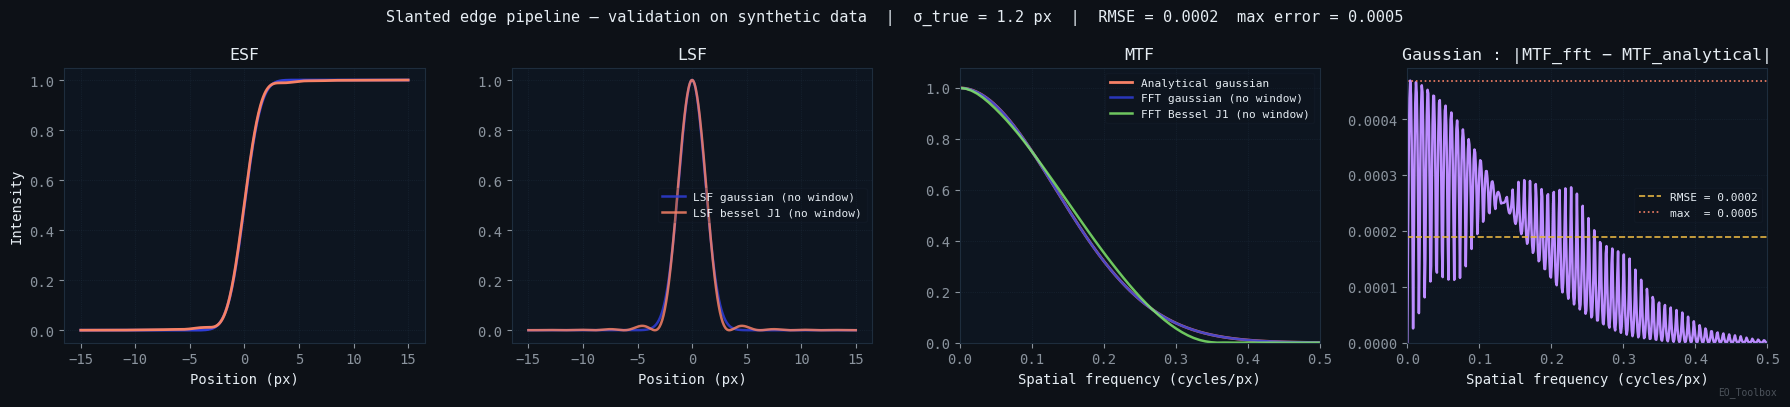

In [43]:
plt.close('all')

from scipy.interpolate import interp1d

sigma_true = 1.2 # ground truth
x   = np.linspace(-15, 15, 500)
dx  = x[1] - x[0]

# Gaussian FFT MTF
ESF = 0.5 * (1 + erf(x / (sigma_true * np.sqrt(2))))
freq_fft, MTF_fft, LSF_windowed, LSF = compute_MTF_slanted_edge(ESF, x, window="none", plot=False)

# Gaussian Analytical MTF
freq_ana = np.linspace(0, 0.5, 500)
MTF_ana  = np.exp(-2 * (np.pi * sigma_true * freq_ana) ** 2)


### Fit bessel LSF on gaussian FWHM ###
from scipy.special import j1

def compute_fwhm(x, y):
    y = y / np.max(y)
    idx = np.where(y >= 0.5)[0]
    return x[idx[-1]] - x[idx[0]]

# Airy PSF (1D cut)
def airy_psf_1d(x, alpha=1.0):
    r = np.abs(x)
    eps = 1e-12
    z = np.pi * alpha * r + eps
    psf = (2 * j1(z) / z)**2
    return psf / np.sum(psf)

def mtf_airy_analytical(freq, fc):
    nu = freq / fc
    mtf = np.zeros_like(freq)
    mask = nu <= 1
    nu_valid = nu[mask]
    mtf[mask] = (2/np.pi) * ( np.arccos(nu_valid) - nu_valid * np.sqrt(1 - nu_valid**2))
    return mtf

target_fwhm = 2.355 * sigma_true
alphas = np.linspace(0.1, 2.0, 200)
best_alpha = None
best_err = 1e9

for a in alphas:
    lsf = airy_psf_1d(x, alpha=a)
    fwhm = compute_fwhm(x, lsf)
    err = abs(fwhm - target_fwhm)
    
    if err < best_err:
        best_err = err
        best_alpha = a

### Compute bessel J1 fft ###
LSF_airy = airy_psf_1d(x, alpha=best_alpha)

ESF_airy = np.cumsum(LSF_airy) * dx
ESF_airy = (ESF_airy - ESF_airy.min()) / (ESF_airy.max() - ESF_airy.min())
freq_fft_a, MTF_fft_a, _, _ = compute_MTF_slanted_edge(ESF_airy, x, window="none", plot=False)

LSF_display = LSF_windowed / np.max(LSF)
LSF_airy_display = LSF_airy / np.max(LSF_airy)

### Error computation on gaussian model ###
MTF_fft_interp = interp1d(freq_fft, MTF_fft, bounds_error=False, fill_value=np.nan)
MTF_fft_on_ana = MTF_fft_interp(freq_ana)
error  = np.abs(MTF_fft_on_ana - MTF_ana)
mask   = freq_ana <= 0.5
RMSE   = np.sqrt(np.nanmean(error[mask] ** 2))
maxerr = np.nanmax(error[mask])

fig, axes = plt.subplots(1, 4, figsize=(18, 4), facecolor=DARK_BG)
fig.suptitle(f"Slanted edge pipeline — validation on synthetic data  |  "f"σ_true = {sigma_true} px  |  RMSE = {RMSE:.4f}  max error = {maxerr:.4f}", fontsize=11, color=TEXT_COL)

# ESF
axes[0].plot(x, ESF, color=BLUE, lw=2)
axes[0].plot(x, ESF_airy, color=ORANGE, lw=2)
axes[0].set_title("ESF", color=TEXT_COL)
axes[0].set_xlabel("Position (px)")
axes[0].set_ylabel("Intensity")

# LSF
axes[1].plot(x, LSF_display, color=BLUE,  lw=1.8, label="LSF gaussian (no window)", alpha=0.85)
axes[1].plot(x, LSF_airy_display, color=ORANGE,  lw=1.8, label="LSF bessel J1 (no window)", alpha=0.85)
axes[1].set_title("LSF", color=TEXT_COL)
axes[1].set_xlabel("Position (px)")
axes[1].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

# MTF
axes[2].plot(freq_ana, MTF_ana, color=ORANGE, lw=2,   label="Analytical gaussian")
axes[2].plot(freq_fft, MTF_fft, color=BLUE,   lw=1.8, label="FFT gaussian (no window)", alpha=0.85)
axes[2].plot(freq_fft, MTF_fft_a, color=LIGHT_GREEN,   lw=1.8, label="FFT Bessel J1 (no window)", alpha=0.85)
axes[2].set_xlim(0, 0.5)
axes[2].set_ylim(0, 1.08)
axes[2].set_title("MTF", color=TEXT_COL)
axes[2].set_xlabel("Spatial frequency (cycles/px)")
axes[2].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

# Erreur absolue
axes[3].plot(freq_ana[mask], error[mask], color=PURPLE, lw=1.8)
axes[3].axhline(RMSE,   color=YELLOW, lw=1.2, linestyle="--", label=f"RMSE = {RMSE:.4f}")
axes[3].axhline(maxerr, color=ORANGE, lw=1.2, linestyle=":", label=f"max  = {maxerr:.4f}")
axes[3].set_xlim(0, 0.5)
axes[3].set_ylim(bottom=0)
axes[3].set_title("Gaussian : |MTF_fft − MTF_analytical|", color=TEXT_COL)
axes[3].set_xlabel("Spatial frequency (cycles/px)")
axes[3].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

for ax in axes:
    style_ax(ax)
watermark(fig)
plt.tight_layout()
plt.show()

## 3. Numerical sensitivities

The MTF estimate from Section 2 was obtained on perfect synthetic data: no noise, infinite support, no numerical approximation.

In practice, three choices affect the result:

- **Spatial support**: how many pixels of ESF are available
- **Windowing**: whether the LSF is tapered before the FFT
- **FFT size**: how densely the frequency axis is sampled

And one physical reality complicates everything:
- **Noise**: the ESF extracted from a real image is never clean

Each of the following subsections isolates one effect, quantifies its impact on the MTF estimate and establishes when and how to mitigate it.
The baseline from Section 2a (RMSE ≈ 0.0002) serves as the reference throughout this section.

### 3a. Truncation - ringing due to finite LSF support

The measured LSF always has finite support (LSF edges not equal to zero, so ESF with no flat edges) as the ESF is sampled over a limited spatial window. Truncating a signal in space is equivalent to multiplying it by a rectangular window, whose Fourier transform is a sinc. This convolution produces **ringing oscillations** in the MTF: the Gibbs phenomenon. The shorter the support, the wider the sinc, and the stronger the oscillations. A wider spatial support reduces the effect (but in practice the available support is limited by the size of the uniform region around the edge in the image).

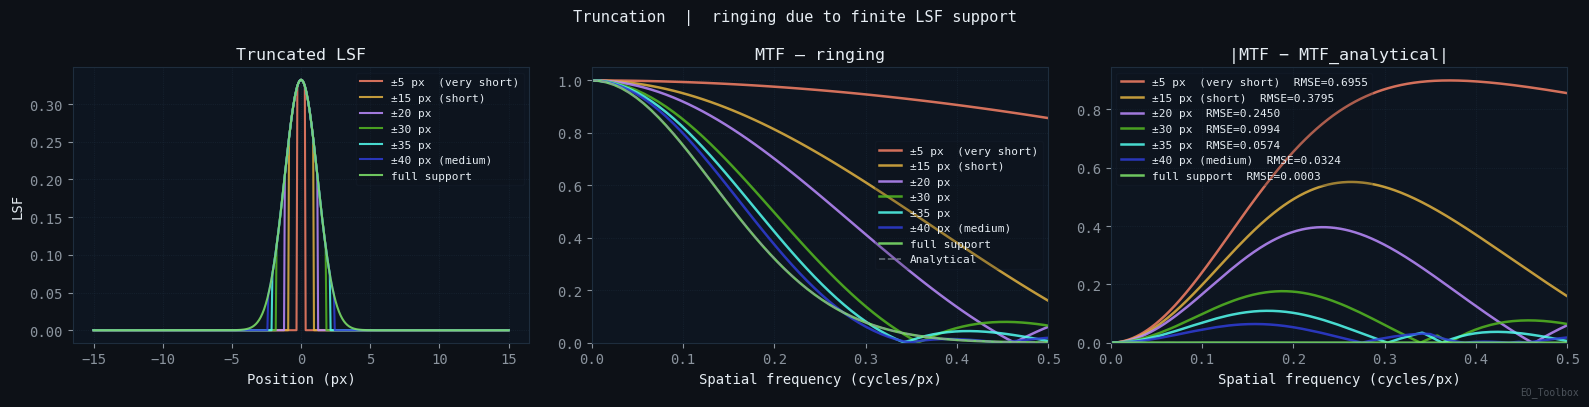

In [44]:
plt.close('all')

i_center = np.argmax(LSF)
supports = {
    "±5 px  (very short)": (5,         ORANGE),
    "±15 px (short)":      (15,        YELLOW),
    "±20 px":              (20,        PURPLE),
    "±30 px":              (30,        RED),
    "±35 px":              (35,        TURQUOISE),
    "±40 px (medium)":     (40,        BLUE),
    "full support":        (len(LSF)//2, LIGHT_GREEN)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=DARK_BG)
fig.suptitle("Truncation  |  ringing due to finite LSF support", fontsize=11, color=TEXT_COL)

mtf_trunc = {}
mask = freq_ana <= 0.5
for label, (half, color) in supports.items():

    lsf_crop = np.zeros_like(LSF)
    lo, hi = max(i_center - half, 0), min(i_center + half, len(LSF))
    lsf_crop[lo:hi] = LSF[lo:hi]

    esf_crop = np.cumsum(lsf_crop) * dx
    esf_crop = (esf_crop - esf_crop.min()) / (esf_crop.max() - esf_crop.min())

    freq, mtf, _, _ = compute_MTF_slanted_edge(esf_crop, x, window="none", plot=False)
    m_interp = interp1d(freq, mtf, bounds_error=False, fill_value=np.nan)
    error    = np.abs(m_interp(freq_ana) - MTF_ana)
    RMSE     = np.sqrt(np.nanmean(error[mask] ** 2))
    
    axes[0].plot(x, lsf_crop, color=color, lw=1.5, label=label, alpha=0.85)
    axes[1].plot(freq, mtf, color=color, lw=1.8, label=label, alpha=0.85)
    axes[2].plot(freq_ana[mask], error[mask], color=color, lw=1.8, label=f"{label}  RMSE={RMSE:.4f}", alpha=0.85)

    mtf_trunc[label] = (freq, mtf, color)

axes[1].plot(freq_ana, MTF_ana, color=MUTED, lw=1.2, linestyle="--", label="Analytical", alpha=0.7)
axes[2].plot(freq_ana, np.zeros_like(freq_ana), color=MUTED, lw=0.8, linestyle="--", alpha=0.3)

axes[0].set_title("Truncated LSF", color=TEXT_COL)
axes[0].set_xlabel("Position (px)")
axes[0].set_ylabel("LSF")
axes[0].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(bottom=0)
axes[1].set_title("MTF — ringing", color=TEXT_COL)
axes[1].set_xlabel("Spatial frequency (cycles/px)")
axes[1].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

axes[2].set_xlim(0, 0.5)
axes[2].set_ylim(bottom=0)
axes[2].set_title("|MTF − MTF_analytical|", color=TEXT_COL)
axes[2].set_xlabel("Spatial frequency (cycles/px)")
axes[2].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

for ax in axes:
    style_ax(ax)
watermark(fig)
plt.tight_layout()
plt.show()

### 3b. Windowing - bias on clean data

Window functions taper the LSF to zero at the edges, reducing spectral leakage. On clean data it introduces a systematic bias. The window attenuates the LSF tails, which carry real signal energy. In the frequency domain this broadens the main lobe. The windowed MTF underestimates contrast in the mid-frequency range, where the slope is steepest.

The bias does not peak at high frequencies, it peaks where the MTF changes most rapidly, typically 0.1–0.2 cycles/px for a Gaussian PSF with σ ≈ 1.5 px. At high frequencies the MTF is already near zero, so the absolute error is small even if the relative error is large. The error panel quantifies this directly against the analytical ground truth.

**On clean data, no window minimizes the error.**
The case for windowing appears when noise is present — see Section 3c.

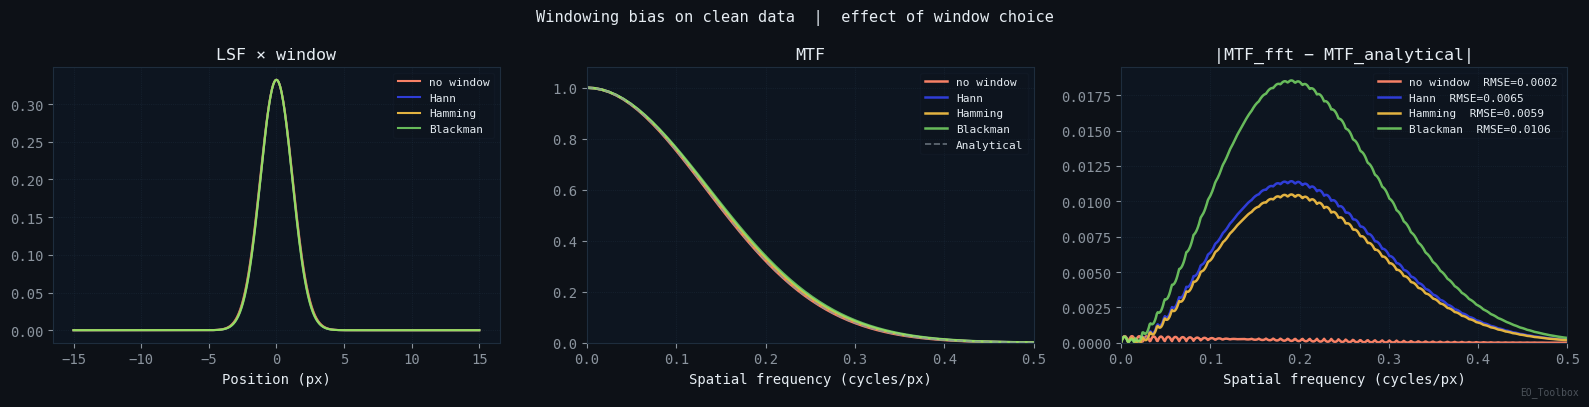

In [49]:
plt.close('all')

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=DARK_BG)
fig.suptitle("Windowing bias on clean data  |  effect of window choice", fontsize=11, color=TEXT_COL)

windows = {"no window": ("none", ORANGE), "Hann": ("hann", BLUE), "Hamming": ("hamming", YELLOW), "Blackman":  ("blackman", LIGHT_GREEN)}

# left : LSF × window
x   = np.linspace(-15, 15, 500)
w_dict = {"none": np.ones(len(LSF)), "hann": np.hanning(len(LSF)), "hamming": np.hamming(len(LSF)), "blackman": np.blackman(len(LSF))}
for label, (wname, color) in windows.items():
    axes[0].plot(x, LSF * w_dict[wname], color=color, lw=1.5, label=label)

axes[0].set_title("LSF × window", color=TEXT_COL)
axes[0].set_xlabel("Position (px)")
axes[0].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

# middle : MTF
mtf_results = {}
for label, (wname, color) in windows.items():
    f, m, _, _ = compute_MTF_slanted_edge(ESF, x, window=wname, plot=False)
    mtf_results[label] = (f, m, color)
    axes[1].plot(f, m, color=color, lw=1.8, label=label)

axes[1].plot(freq_ana, MTF_ana, color=MUTED, lw=1.2, linestyle="--", label="Analytical", alpha=0.7)
axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(0, 1.08)
axes[1].set_title("MTF", color=TEXT_COL)
axes[1].set_xlabel("Spatial frequency (cycles/px)")
axes[1].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

# right : erreur absolue
for label, (f, m, color) in mtf_results.items():
    m_interp = interp1d(f, m, bounds_error=False, fill_value=np.nan)
    m_on_ana = m_interp(freq_ana)
    error    = np.abs(m_on_ana - MTF_ana)
    mask     = freq_ana <= 0.5
    RMSE     = np.sqrt(np.nanmean(error[mask] ** 2))
    axes[2].plot(freq_ana[mask], error[mask], color=color, lw=1.8,
                 label=f"{label}  RMSE={RMSE:.4f}")

axes[2].set_xlim(0, 0.5)
axes[2].set_ylim(bottom=0)
axes[2].set_title("|MTF_fft − MTF_analytical|", color=TEXT_COL)
axes[2].set_xlabel("Spatial frequency (cycles/px)")
axes[2].legend(fontsize=8, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

for ax in axes:
    style_ax(ax)
watermark(fig)
plt.tight_layout()
plt.show()

### 3c. Noise — when windowing becomes useful

On a real image the ESF is never clean. Detector noise propagates through the gradient to the LSF, and then through the FFT to the MTF.

Two effects appear:
- **noise floor**: the MTF is biased upward at high frequencies
- **oscillations**: the noisy LSF introduces erratic spectral content

In this regime, windowing trades bias for variance reduction. The window attenuates the noisy tails of the LSF, suppressing oscillations at the cost of the systematic underestimation seen in Section 3b. The four columns below show the same comparison at increasing noise levels. At low SNR, the no-window estimate deteriorates rapidly. Windowed estimation become more stable and closer to the analytical curve.

The optimal window depends on SNR:
- High SNR (clean data) → no window
- Low SNR (noisy data)  → Hann or Hamming

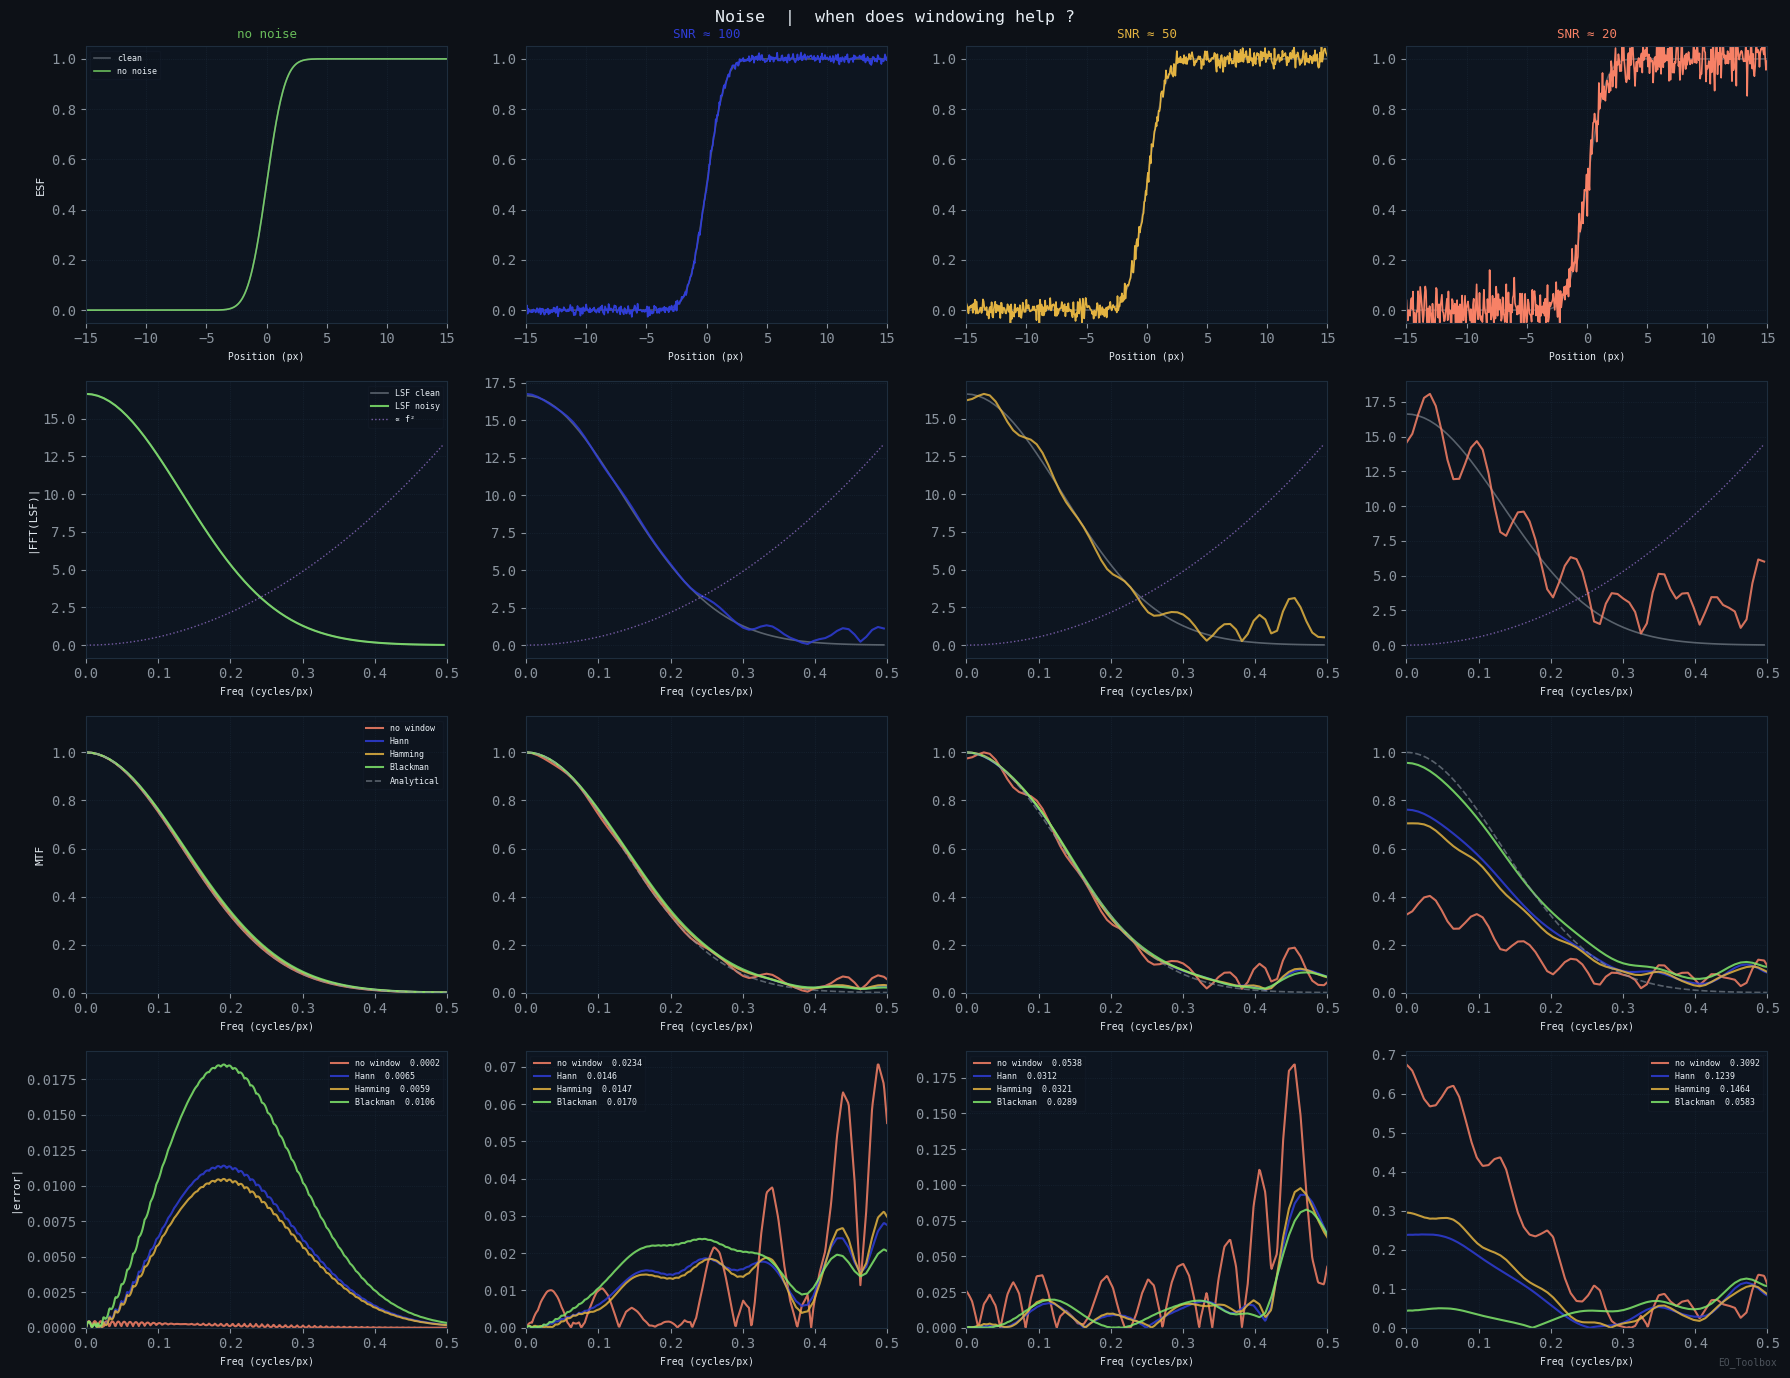

In [ ]:
plt.close('all')

np.random.seed(42)

noise_levels = {
    "no noise":   0.000,
    "SNR ≈ 100":  0.01,
    "SNR ≈ 50":   0.02,
    "SNR ≈ 20":   0.05}
noise_colors = [LIGHT_GREEN, BLUE, YELLOW, ORANGE]

windows_3d = {
    "no window": ("none",     ORANGE),
    "Hann":      ("hann",     BLUE),
    "Hamming":   ("hamming",  YELLOW),
    "Blackman":  ("blackman", LIGHT_GREEN)}

_, _, _, LSF_clean = compute_MTF_slanted_edge(ESF, x, window="none", plot=False)

n_fft_spec = 2048
freq_spec  = np.fft.rfftfreq(n_fft_spec, dx)
mask_spec  = freq_spec <= 0.5
spec_clean = np.abs(np.fft.rfft(LSF_clean, n_fft_spec))

fig, axes = plt.subplots(4, 4, figsize=(18, 14), facecolor=DARK_BG)
fig.suptitle("Noise  |  when does windowing help ?", fontsize=12, color=TEXT_COL)

for col, ((noise_label, noise_std), ncolor) in enumerate(
        zip(noise_levels.items(), noise_colors)):

    ESF_n = ESF + np.random.normal(0, noise_std, size=ESF.shape)

    _, _, _, LSF_n = compute_MTF_slanted_edge(ESF_n, x, window="none", plot=False)
    spec_noisy = np.abs(np.fft.rfft(LSF_n, n_fft_spec))

    mtf_row = {}
    for label, (wname, color) in windows_3d.items():
        f, m, _, _ = compute_MTF_slanted_edge(ESF_n, x, window=wname, plot=False)
        mtf_row[label] = (f, m, color)

    ax_esf = axes[0, col]
    ax_esf.plot(x, ESF,   color=MUTED,  lw=1.2, alpha=0.5, label="clean")
    ax_esf.plot(x, ESF_n, color=ncolor, lw=1.2, label=noise_label)
    ax_esf.set_xlim(x[0], x[-1])
    ax_esf.set_ylim(-0.05, 1.05)
    ax_esf.set_title(noise_label, color=ncolor, fontsize=9)
    ax_esf.set_xlabel("Position (px)", fontsize=7)
    if col == 0:
        ax_esf.set_ylabel("ESF", fontsize=8)
        ax_esf.legend(fontsize=6, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)
    style_ax(ax_esf)

    ax_spec = axes[1, col]
    ax_spec.plot(freq_spec[mask_spec], spec_clean[mask_spec],
                 color=MUTED,  lw=1.2, alpha=0.6, label="LSF clean")
    ax_spec.plot(freq_spec[mask_spec], spec_noisy[mask_spec],
                 color=ncolor, lw=1.5, alpha=0.85, label="LSF noisy")
    f2_ref = freq_spec[mask_spec] ** 2
    if f2_ref.max() > 0:
        f2_ref = f2_ref / f2_ref.max() * spec_noisy[mask_spec].max() * 0.8
        ax_spec.plot(freq_spec[mask_spec], f2_ref,
                     color=PURPLE, lw=1.0, linestyle=":", alpha=0.6, label="∝ f²")
    ax_spec.set_xlim(0, 0.5)
    ax_spec.set_xlabel("Freq (cycles/px)", fontsize=7)
    if col == 0:
        ax_spec.set_ylabel("|FFT(LSF)|", fontsize=8)
        ax_spec.legend(fontsize=6, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)
    style_ax(ax_spec)

    ax_mtf = axes[2, col]
    for label, (f, m, color) in mtf_row.items():
        ax_mtf.plot(f, m, color=color, lw=1.5, label=label, alpha=0.85)
    ax_mtf.plot(freq_ana, MTF_ana, color=MUTED, lw=1.2, linestyle="--", alpha=0.6, label="Analytical")
    ax_mtf.set_xlim(0, 0.5)
    ax_mtf.set_ylim(0, 1.15)
    ax_mtf.set_xlabel("Freq (cycles/px)", fontsize=7)
    if col == 0:
        ax_mtf.set_ylabel("MTF", fontsize=8)
        ax_mtf.legend(fontsize=6, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)
    style_ax(ax_mtf)

    ax_err = axes[3, col]
    for label, (f, m, color) in mtf_row.items():
        m_interp = interp1d(f, m, bounds_error=False, fill_value=np.nan)
        error    = np.abs(m_interp(freq_ana) - MTF_ana)
        mask     = freq_ana <= 0.5
        RMSE     = np.sqrt(np.nanmean(error[mask] ** 2))
        ax_err.plot(freq_ana[mask], error[mask], color=color, lw=1.5, label=f"{label}  {RMSE:.4f}", alpha=0.85)
    ax_err.set_xlim(0, 0.5)
    ax_err.set_ylim(bottom=0)
    ax_err.set_xlabel("Freq (cycles/px)", fontsize=7)
    if col == 0:
        ax_err.set_ylabel("|error|", fontsize=8)
    ax_err.legend(fontsize=6, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)
    style_ax(ax_err)

watermark(fig)
plt.tight_layout()
plt.show()

## Summary

| Effect | Cause | Observable | Mitigation |
|---|---|---|---|
| Ringing | LSF truncation (finite spatial support) | Gibbs oscillations in MTF | extend ESF/LSF support |
| Spectral leakage | abrupt LSF boundaries | oscillations in MTF | apply window (Hann, Hamming, Blackman) |
| Windowing bias | window attenuates LSF tails | MTF underestimated at mid-frequencies | use window only when noise is present |
| Noise floor | detector noise amplified by derivation | MTF biased upward at high frequencies | windowing, or parametric fit (see Notebook 2) |

*Full toolbox available as part of consulting engagements — floragabriagues.github.io*